In [1]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import numpy as np

import copy
import torch
from torch import Tensor, nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

from common.const import DATASET_PATH
from common.util import *
from common.meta import MetaData
from common.optimise_v3 import NetLineStepProcessor

from torchvision.datasets import CIFAR10
from torchvision import transforms, models

import logging

In [2]:
logging.basicConfig(filename="log_restnet18_cifar10_epoch1d.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")


#### CIFAR10 dataset

In [3]:
# Convert from PIL to torch.Tensort
# and normalize each pixel from [0, 255] range to [0.0, 1.0]
base_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
#base_transforms = transforms.ToTensor()

# An augmentation that randomly (with a probability equal to 0.5)
# flips the image horizontally
# This will prevent overfitting and make the model more robust
aug_transforms = transforms.RandomHorizontalFlip(p=0.5)

# Gather all transforms together
train_transforms = transforms.Compose([
    base_transforms,
    aug_transforms
])

train_dataset = CIFAR10(root=DATASET_PATH, train=True, download=True, transform=train_transforms)

# Note that we only use `base_transforms` for test dataset
test_dataset = CIFAR10(root=DATASET_PATH, train=False, download=True, transform=base_transforms)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
BATCH_SIZE = 128 #128 #64 #64 #32

# `pin_memory` speed up processing if you use GPU
# `num_workers` also speed up processing since use additional process
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             num_workers=0, pin_memory=True)

In [5]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.1
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

INPUT_DIM=32*32
OUTPUT_DIM = 10
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

lb, lw = 0.005, 5.0
meta = MetaData(input_dim = INPUT_DIM, output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE, reduction='mean', device=DEVICE)



##### UTILS

#### Compare optimisers

In [6]:
def visualise(history_params):
    # visualize all together
    display.clear_output()
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    axes[0, 0].set_title('Loss (cross-entropy)')
    axes[0, 0].plot(history_params['train_loss'], label='Train Loss')
    axes[0, 0].plot(history_params['test_loss'], label='Test Loss')
    axes[0, 0].grid()
    axes[0, 0].legend(fontsize=20)
    
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].plot(history_params['train_accuracy'], label='Train Accuracy')
    axes[0, 1].plot(history_params['test_accuracy'], label='Test Accuracy')
    axes[0, 1].grid()
    axes[0, 1].legend(fontsize=20)

    axes[1, 0].set_title('Params eta')
    axes[1, 0].plot(history_params['train_eta'])
    axes[1, 0].grid()

    axes[1, 1].set_title('Raw params eta')
    axes[1, 1].plot(history_params['train_eta_raw'])
    axes[1, 1].grid()    
    #ax2.legend(fontsize=20)
    
    plt.show()


#### Reference CNN

In [7]:
def make_model():
    model = models.resnet18(weights=None) #torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', weights=None)
    model.fc = nn.Linear(512, OUTPUT_DIM)
    return model

In [8]:
HISTORY_NORM2 = collections.defaultdict(list)
#HISTORY_OPTFIX = collections.defaultdict(list)

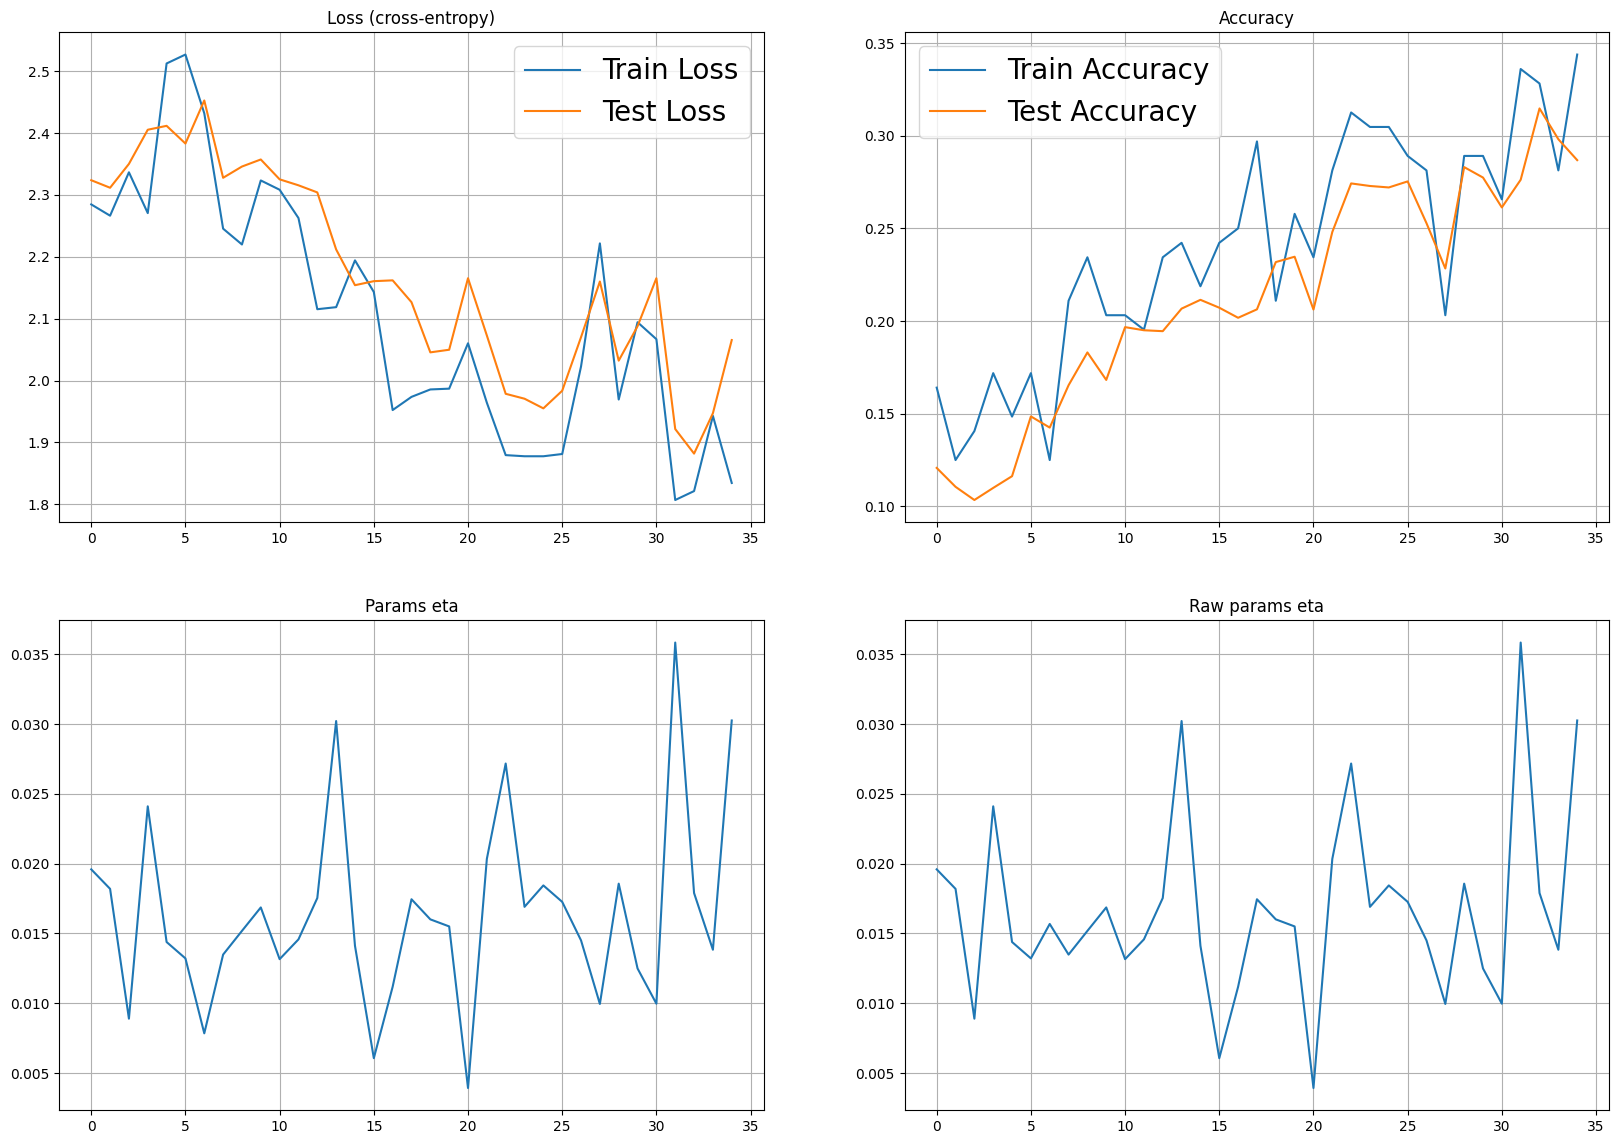

accuracy:
norm2=0.2867879746835443, 
loss=2.065402708476103


KeyboardInterrupt: 

In [9]:
def test_loop(testNet, test_loss_meter, test_accuracy_meter):
    for test_batch in test_dataloader:
        images, labels = test_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            logits = testNet.forward(images)

            zz_logits = np.transpose(logits.detach().cpu().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(calculate_accuracy(prediction, labels))

NUM_EPOCH = 1
eta_fixed = 0.01

testNorm2S = make_model().to(DEVICE)
stepProcessor = NetLineStepProcessor(testNorm2S, nn.CrossEntropyLoss(), meta, DEVICE)

use_ones=False
for epoch in range(NUM_EPOCH):
    lr = eta_fixed if epoch < 20 else eta_fixed * 0.1 if epoch < 40 else eta_fixed * 0.01
    do_dropout = True #not(epoch < 20)

    stepProcessor.c1 = 0.001 #0.25 #0.499 #if epoch < 1 else 0.01 #1/30
    stepProcessor.eta_cos_negative = lr
    stepProcessor.eta_max = lr *5 #0.25
    stepProcessor.eta_min = lr *0.01 #eta_fixed if epoch < 20 else eta_fixed * 0.1 if epoch < 40 else eta_fixed * 0.01 # #0.0001 if epoch < 1 else
    stepProcessor.eta0 = 0.000_000_25
    stepProcessor.momentum_gradient_smoothing_coefficient = 5.0 #if epoch < 1 else 0.0
    stepProcessor.iter_max = 10
    
    stepProcessor.training_mode=do_dropout
    step_params = {"estimation_type": 'analytic-norm2'} #, "check_additional": False, "check_additional": False, 'check_armiho': False} #{"check_additional": False, 'check_armiho': False}

    testNorm2S.train(False) #if epoch < 1 else {"estimation_type": 'iter-ones-norm2'}

    iter=-1
    for train_batch in train_dataloader:
        images, labels = train_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        pp = labels_to_softhot(labels, meta.output_dim)
        iter+=1

        logging.info("##\n --==Epoch={}, iter={}==--".format(epoch, iter))
        logging.info("####Step with net-line norm2")
        step_result = stepProcessor.step(labels, images, momentum=0.9, nesterov=True, step_params=step_params)
        logits_latest = step_result.logits.detach()

        # calculate current average loss and accuracy
        zz_logits = np.transpose(logits_latest.cpu().numpy())
        prediction = logits_latest.argmax(dim=-1)
        loss = loss_crossentropy(zz_logits, labels)
        # save average train loss and accuracy
        HISTORY_NORM2['train_loss'].append(loss)
        HISTORY_NORM2['train_accuracy'].append(calculate_accuracy(prediction,labels))
        HISTORY_NORM2['train_eta'].append(step_result.eta)
        HISTORY_NORM2['train_eta_raw'].append(step_result.eta_raw)
        HISTORY_NORM2['train_armiho'].append(step_result.ck_armiho)
        HISTORY_NORM2['train_wolf'].append(step_result.ck_wolf)

        testNorm2S.eval()
        # testing loop
        test_loss2S_meter, test_accuracy2S_meter = AverageMeter(), AverageMeter(),
        test_loop(testNorm2S, test_loss2S_meter, test_accuracy2S_meter)
        HISTORY_NORM2['test_loss'].append(test_loss2S_meter.avg)
        HISTORY_NORM2['test_accuracy'].append(test_accuracy2S_meter.avg) 
    
        visualise(HISTORY_NORM2)
        print("accuracy:\nnorm2={}, \nloss={}"\
            .format(HISTORY_NORM2['test_accuracy'][-1], HISTORY_NORM2['test_loss'][-1]))
